# DRL Assignment 1 — Part 2 (DP)
## Autonomous Drone Rescue Using Dynamic Programming (Value Iteration)

This notebook implements all five required tasks:

1. **Task 1** — Custom Drone Rescue environment
2. **Task 2** — Dynamic Programming: Value Iteration
3. **Task 3** — Policy Visualization
4. **Task 4** — State-Value Heatmap Analysis
5. **Task 5** — DP Scalability Discussion 

In [16]:
from datetime import datetime
import platform

print('Execution Timestamp:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Virtual Machine ID:', platform.node() or 'unknown-host')

Execution Timestamp: 2026-06-08 11:44:40
Virtual Machine ID: LAMU0M273T0GKX1.uhc.com.


---
## Common Imports & Type Definitions

Shared infrastructure used across all task cells.


In [9]:
# ============================================================
# COMMON IMPORTS & TYPE DEFINITIONS
# ------------------------------------------------------------
# Shared by all task cells — must be run first.
#   - Action        : integer action id (0=U, 1=D, 2=L, 3=R, 4=H)
#   - State         : (row, col, battery, rescued_mask) tuple
#   - DPResult      : output container from value iteration
# ============================================================

from dataclasses import dataclass, field
from typing import Dict, List, Optional, Set, Tuple
import random
import time

import numpy as np
import matplotlib.pyplot as plt


# Type aliases for readability throughout the notebook.
Action = int
State  = Tuple[int, int, int, int]   # (row, col, battery, rescued_mask)


@dataclass
class DPResult:
    """Output container for value iteration.

    Attributes:
        values        : V*(s) for every reachable state.
        policy        : π*(s) — greedy action for every non-terminal state.
        iterations    : number of full Bellman sweeps until convergence.
        final_delta   : last max residual (should be < theta).
        runtime_sec   : wall-clock time for the entire VI run.
        delta_history : max Bellman residual recorded after every sweep
                        — used to plot the convergence curve.
    """
    values:        Dict[State, float]
    policy:        Dict[State, Action]
    iterations:    int
    final_delta:   float
    runtime_sec:   float
    delta_history: List[float] = field(default_factory=list)

---
## Task 1 — Custom Drone Rescue Environment

**Objective:** Implement a finite MDP environment for the autonomous drone rescue problem, including `reset()`, `step(action)`, and `render()`.

---

### 1.1 Group 37 — Grid Parameters

Our group number is 37, last digit = 7 (falls in the 5–9 branch), which fixes the following:

| Parameter | Value | Rule applied |
|-----------|-------|--------------|
| Grid size | 6 × 6 | last digit 7 → ends in 5–9 |
| Rescue targets | 3 | last digit 5–9 |
| Charging stations | 2 | last digit 5–9 |
| Danger zones | 4 | last digit 5–9 |
| Blocked cells | 3 | last digit 5–9 |
| Wind probability | 30 % | last digit 5–9 |
| Max battery (starting) | **15 units** | last digit odd (7) |
| Max steps per episode | 75 | 6×6 grid |

Drone always starts at top-left (0, 0) with full battery and no rescues done (rescued_mask = 0b000).

---

### 1.2 Cell Symbol

| Symbol | Meaning |
|--------|---------|
| `S` | Start — drone begins here, top-left (0, 0) |
| `F` | Free / Safe cell — traversable, no special effect |
| `D` | Danger zone — entering gives −10 reward |
| `R` | Rescue target — completing gives +20 (one-time, cell becomes F) |
| `C` | Charging station — entering gives battery full + +5 reward; hovering gives battery +2 |
| `W` | Wind zone — 30 % chance of random direction when moving |
| `X` | Blocked cell — impassable; drone stays put, battery still consumed |
| `A` | Drone current position (shown by `render()` only) |

Cell positions are seeded by GROUP_ID = 37 so the layout is the same every run.

---

### 1.3 State Representation

Each state is a 4-tuple:

$$s = (row,\ col,\ battery,\ rescued\_mask)$$

| Component | Range | Description |
|-----------|-------|-------------|
| `row` | 0–5 | Drone row on the 6×6 grid |
| `col` | 0–5 | Drone column |
| `battery` | 1–15 | Remaining battery (0 = terminal) |
| `rescued_mask` | 0–7 (3-bit) | Bitmask: bit $i$ set ⟹ rescue target $i$ completed |

**Total reachable states:** upper bound = 6 × 6 × 15 × 2³ = **4 320** (BFS prunes unreachable states).

---

### 1.4 Action Space

Five actions available in every non-terminal state:

| Action ID | Symbol | Effect |
|-----------|--------|--------|
| 0 | ↑ Up | Move `row − 1` |
| 1 | ↓ Down | Move `row + 1` |
| 2 | ← Left | Move `col − 1` |
| 3 | → Right | Move `col + 1` |
| 4 | H Hover | Stay in place |

---

### 1.5 How Movement Works

**Normal cells**: the drone moves exactly where it intends. If the target is out-of-bounds or blocked, it stays put (battery is still spent).

**Wind cells**: when standing on a W cell and choosing a movement action:

| Outcome | Probability | Result |
|---------|-------------|--------|
| Intended direction | $1 - p_{wind} = 0.70$ | Drone moves as requested |
| Random direction | $p_{wind} = 0.30$ | Actual direction drawn uniformly from {Up, Down, Left, Right} |


Hover is  **never affected by wind**.

Hovering on a charging station: net +2 battery per step (the normal −1 step cost is waived).

---

### 1.6 Reward Structure

| Event | Reward |
|-------|--------|
| Any action (base cost) | −1 |
| Enter a danger zone | −10 (episode continues) |
| Complete a rescue (first visit) | +20 (mask updated; cell becomes F) |
| Enter a charging station | +5, battery → full |
| Battery exhaustion (battery → 0) | −20 (terminal) |
| All rescues complete | — (terminal, positive outcome) |

---

### 1.7 Episode Termination

An episode ends when **any** of the following occur:
- Battery reaches **0** → −20 penalty, terminal
- All **3 rescue targets** completed → terminal (success)
- Step count reaches **75** → truncated

In [19]:
class DroneRescueEnv:
    """Finite MDP for the autonomous drone rescue problem.

    State space: (row, col, battery, rescued_mask)
        - row, col      : current drone position on the grid
        - battery       : remaining battery units (0 = dead)
        - rescued_mask  : bitmask — bit i set means rescue target i is done

    Actions: 0=Up  1=Down  2=Left  3=Right  4=Hover

    Assignment-driven parameters (Group 37, last digit = 7 → 5–9 branch):
        Grid      : 6×6
        Rescue    : 3 targets
        Charging  : 2 stations
        Danger    : 4 zones
        Blocked   : 3 cells
        Wind prob : 30%
        Battery   : 15 (odd last digit)
        Max steps : 75
    """

    # Action map: id → (Δrow, Δcol, symbol)
    ACTIONS: Dict[Action, Tuple[int, int, str]] = {
        0: (-1,  0, "↑"),   # Up
        1: ( 1,  0, "↓"),   # Down
        2: ( 0, -1, "←"),   # Left
        3: ( 0,  1, "→"),   # Right
        4: ( 0,  0, "H"),   # Hover
    }

    def __init__(self, group_id: int, seed: Optional[int] = None) -> None:
        self.group_id   = group_id
        self.last_digit = group_id % 10
        self.rng        = random.Random(group_id if seed is None else seed)

        # ── Grid size and cell counts determined by last digit of group ID ──
        if self.last_digit <= 4:
            self.rows, self.cols = 5, 5
            self.n_rescue   = 2
            self.n_charge   = 1
            self.n_danger   = 3
            self.n_blocked  = 2
            self.wind_prob  = 0.20
            self.max_steps  = 50
        else:   # Group 37 → last digit 7 uses this branch
            self.rows, self.cols = 6, 6
            self.n_rescue   = 3
            self.n_charge   = 2
            self.n_danger   = 4
            self.n_blocked  = 3
            self.wind_prob  = 0.30
            self.max_steps  = 75

        # Battery max: even last digit → 10, odd → 15  (Group 37 → 15)
        self.max_battery = 10 if (self.last_digit % 2 == 0) else 15

        # Start is fixed at top-left (per assignment spec).
        self.start = (0, 0)

        # Cell-type sets (populated deterministically by _build_layout).
        self.blocked:        Set[Tuple[int, int]] = set()
        self.danger:         Set[Tuple[int, int]] = set()
        self.charging:       Set[Tuple[int, int]] = set()
        self.wind:           Set[Tuple[int, int]] = set()
        self.rescue_points:  List[Tuple[int, int]] = []

        self._build_layout()

        # rescue_index: maps each rescue cell → its bit position in rescued_mask
        self.rescue_index = {pos: i for i, pos in enumerate(self.rescue_points)}

        # Runtime state — updated by reset() and step()
        self.state:      Optional[State] = None
        self.step_count: int = 0

    #  Layout construction 

    def _cell_pool(self) -> List[Tuple[int, int]]:
        """Return all grid cells except the fixed start cell (0, 0)."""
        return [(r, c) for r in range(self.rows)
                       for c in range(self.cols)
                       if  (r, c) != self.start]

    def _sample_cells(
        self, pool: List[Tuple[int, int]], n: int
    ) -> List[Tuple[int, int]]:
        """Draw n distinct cells from pool (without replacement), remove them."""
        selected = self.rng.sample(pool, n)
        for cell in selected:
            pool.remove(cell)
        return selected

    def _build_layout(self) -> None:
        """Assign cell types deterministically using the group-seeded RNG.

        Order matters: blocked → danger → charging → rescue → wind.
        This guarantees the same layout for any run with the same GROUP_ID.
        """
        pool = self._cell_pool()
        self.blocked       = set(self._sample_cells(pool, self.n_blocked))
        self.danger        = set(self._sample_cells(pool, self.n_danger))
        self.charging      = set(self._sample_cells(pool, self.n_charge))
        self.rescue_points = self._sample_cells(pool, self.n_rescue)
        n_wind = 2 if self.rows == 5 else 3   # 2 wind zones for 5×5, 3 for 6×6
        self.wind = set(self._sample_cells(pool, n_wind))

    #  Core MDP interface 

    def reset(self) -> State:
        """Reset episode: drone at start, full battery, no rescues completed.

        Returns:
            Initial state (row=0, col=0, battery=max_battery, mask=0).
        """
        self.state      = (self.start[0], self.start[1], self.max_battery, 0)
        self.step_count = 0
        return self.state

    def in_bounds(self, r: int, c: int) -> bool:
        """Return True if (r, c) is a valid grid cell."""
        return 0 <= r < self.rows and 0 <= c < self.cols

    def is_terminal(self, state: State) -> bool:
        """Episode terminates when battery = 0 OR all rescues are complete."""
        _, _, battery, mask = state
        return battery <= 0 or mask == (1 << self.n_rescue) - 1

    def valid_actions(self, state: State) -> List[Action]:
        """Return all 5 actions in non-terminal states; empty list otherwise."""
        return [] if self.is_terminal(state) else [0, 1, 2, 3, 4]

    def _attempt_move(
        self, r: int, c: int, action: Action
    ) -> Tuple[int, int]:
        """Compute next position for a movement action.

        If the target cell is out-of-bounds or blocked, the drone stays put
        (battery is still consumed — per assignment spec for blocked cells).
        """
        dr, dc, _ = self.ACTIONS[action]
        nr, nc    = r + dr, c + dc
        if not self.in_bounds(nr, nc) or (nr, nc) in self.blocked:
            return r, c   # Stay in place; battery cost applied by caller
        return nr, nc

    def transition_model(
        self, state: State, action: Action
    ) -> List[Tuple[float, State, float, bool]]:
        """Return the full stochastic transition distribution P(s', r | s, a).

        Wind stochasticity:
            If the drone is on a wind cell (W) and chooses a movement action:
              - With probability (1 - wind_prob): intended direction executes.
              - With probability wind_prob      : direction is drawn uniformly
                                                  from {Up, Down, Left, Right}.
            Hover is NOT affected by wind.

        Reward structure (per assignment):
            - Base movement / hover cost         : -1
            - Entering a charging station        : +5  (battery → full)
            - Hovering on charging station       : battery +2 (no extra reward)
            - Entering a danger zone             : -10
            - Completing a rescue (first visit)  : +20
            - Battery exhaustion (battery → 0)   : -20  (terminal)

        Returns:
            List of (probability, next_state, reward, done) tuples.
            Duplicate next-states are merged via probability-weighted reward.
        """
        if self.is_terminal(state):
            return [(1.0, state, 0.0, True)]

        r, c, battery, mask = state

        # Build list of (probability, actual_action) for wind handling
        if (r, c) in self.wind and action in [0, 1, 2, 3]:
            # Wind: intended direction + random perturbation component
            action_candidates: List[Tuple[float, Action]] = [
                (1.0 - self.wind_prob, action)
            ]
            for a in [0, 1, 2, 3]:
                action_candidates.append((self.wind_prob / 4.0, a))
        else:
            action_candidates = [(1.0, action)]

        # Accumulate outcomes; merge duplicate next-states.
        outcomes: Dict[State, Tuple[float, float, bool]] = {}

        for p_act, actual_action in action_candidates:
            nr, nc       = r, c
            next_battery = battery
            reward       = -1.0   # Every action costs 1 step (base cost)

            if actual_action == 4:
                #  Hover 
                # On a charging station  → net battery +2 (capped at max).
                # Anywhere else          → battery −1 (normal consumption).
                # Assignment: "hovering increases battery by +2 units" when on C.
                if (r, c) in self.charging:
                    next_battery = min(self.max_battery, battery + 2)
                else:
                    next_battery = battery - 1
            else:
                #  Movement 
                # Try to move; stay put if blocked or out-of-bounds.
                nr, nc       = self._attempt_move(r, c, actual_action)
                next_battery = battery - 1   # Always costs 1 battery unit

                # Entering a charging station → full recharge + reward +5
                # Assignment rule 2: "battery becomes full again"
                # Reward table: "Reach charging station: +5"
                if (nr, nc) in self.charging:
                    next_battery = self.max_battery
                    reward += 5.0

            next_mask = mask

            # Danger zone: heavy penalty, episode continues
            # Assignment rule 4: "gives heavy negative reward"
            if (nr, nc) in self.danger:
                reward += -10.0

            # Rescue: one-time reward per target; update bitmask
            # Assignment rule 3: "reward obtained, target disappears"
            if (nr, nc) in self.rescue_index:
                bit = 1 << self.rescue_index[(nr, nc)]
                if not (mask & bit):          # First visit only
                    reward    += 20.0
                    next_mask |= bit

            done = False

            # Battery exhaustion: penalty + terminal
            # Assignment: "If battery becomes 0: episode terminates immediately"
            if next_battery <= 0:
                reward      += -20.0
                next_battery = 0
                done         = True

            # All rescues complete → terminal (successful)
            if next_mask == (1 << self.n_rescue) - 1:
                done = True

            ns = (nr, nc, next_battery, next_mask)

            # Merge outcomes that land in the same next-state.
            # Reward is probability-weighted so that
            #   p_merged * r_merged = p1*r1 + p2*r2  (correct for VI Q-computation)
            if ns in outcomes:
                old_p, old_r, old_d = outcomes[ns]
                merged_r = (old_p * old_r + p_act * reward) / (old_p + p_act)
                outcomes[ns] = (old_p + p_act, merged_r, old_d or done)
            else:
                outcomes[ns] = (p_act, reward, done)

        return [(p, ns, rwd, d) for ns, (p, rwd, d) in outcomes.items()]

    def step(self, action: Action) -> Tuple[State, float, bool, dict]:
        """Sample one stochastic transition and advance episode state.

        Used for trajectory rollout (calls reset() before use).
        """
        assert self.state is not None, "Call reset() before step()."
        choices = self.transition_model(self.state, action)
        probs   = [c[0] for c in choices]
        idx     = np.random.choice(len(choices), p=probs)
        _, ns, reward, done = choices[idx]
        self.state      = ns
        self.step_count += 1
        if self.step_count >= self.max_steps:
            done = True
        return ns, reward, done, {}

    def render(self) -> None:
        """Print the current grid state using assignment cell-type symbols.

        Assignment rule 3: Once a rescue target is completed it 'disappears
        and becomes a free cell (F)'.  This method honours that rule by
        checking the rescued_mask stored in self.state and showing already-
        rescued cells as 'F' rather than 'R'.

        Symbol legend:
            S = Start    F = Free      D = Danger
            R = Rescue   C = Charge    W = Wind
            X = Blocked  A = Drone (current position)
        """
        # Extract current rescued_mask from state (0 if no state yet)
        current_mask = 0
        if self.state:
            _, _, _, current_mask = self.state

        grid = [["F"] * self.cols for _ in range(self.rows)]

        for row_r, col_c in self.blocked:   grid[row_r][col_c] = "X"
        for row_r, col_c in self.danger:    grid[row_r][col_c] = "D"
        for row_r, col_c in self.charging:  grid[row_r][col_c] = "C"
        for row_r, col_c in self.wind:      grid[row_r][col_c] = "W"

        # Rescue targets: show 'R' only if not yet rescued in current state
        for pos in self.rescue_points:
            row_r, col_c = pos
            bit = 1 << self.rescue_index[pos]
            if not (current_mask & bit):
                grid[row_r][col_c] = "R"
            # else: rescue completed → cell is now free (remains "F")

        sr, sc = self.start
        grid[sr][sc] = "S"  # Start overwrites F

        if self.state:
            dr, dc, _, _ = self.state
            grid[dr][dc] = "A"  # Drone position (may overlap start)

        print("\nGrid Layout  (S=Start  F=Free  D=Danger  R=Rescue/not-yet-rescued)")
        print("             (C=Charge  W=Wind  X=Blocked  A=Drone)")
        for row in grid:
            print(" ".join(row))

    def enumerate_reachable_states(self) -> List[State]:
        """BFS from initial state to collect all reachable (non-blocked) states.

        Returns:
            Sorted list of all reachable states for use in value iteration.
        """
        init      = (self.start[0], self.start[1], self.max_battery, 0)
        visited:  Set[State] = {init}
        frontier: List[State] = [init]

        while frontier:
            s = frontier.pop()
            if self.is_terminal(s):
                continue
            for a in self.valid_actions(s):
                for _, ns, _, _ in self.transition_model(s, a):
                    if ns not in visited:
                        visited.add(ns)
                        frontier.append(ns)

        return sorted(visited)


#  Instantiate the environment for Group 37 
GROUP_ID = 37
env      = DroneRescueEnv(GROUP_ID)

print("=" * 55)
print("  Task 1: Custom Drone Rescue Environment — Group 37")
print("=" * 55)
print(f"Group ID          : {env.group_id}")
print(f"Grid size         : {env.rows} × {env.cols}")
print(f"Start position    : {env.start}  (fixed top-left)")
print(f"Max battery       : {env.max_battery} units  (last digit odd → 15)")
print(f"Wind probability  : {env.wind_prob * 100:.0f}%  (last digit 5-9 → 30%)")
print(f"Step limit        : {env.max_steps}  (6×6 grid → 75)")
print(f"Rescue targets    : {env.rescue_points}")
print(f"Charging stations : {sorted(env.charging)}")
print(f"Danger zones      : {sorted(env.danger)}")
print(f"Blocked cells     : {sorted(env.blocked)}")
print(f"Wind zones        : {sorted(env.wind)}")

# Reset so the drone is placed at start before rendering
env.reset()
env.render()

  Task 1: Custom Drone Rescue Environment — Group 37
Group ID          : 37
Grid size         : 6 × 6
Start position    : (0, 0)  (fixed top-left)
Max battery       : 15 units  (last digit odd → 15)
Wind probability  : 30%  (last digit 5-9 → 30%)
Step limit        : 75  (6×6 grid → 75)
Rescue targets    : [(2, 1), (2, 4), (4, 5)]
Charging stations : [(3, 5), (5, 0)]
Danger zones      : [(1, 3), (4, 2), (5, 1), (5, 2)]
Blocked cells     : [(0, 3), (1, 0), (5, 3)]
Wind zones        : [(1, 1), (3, 1), (3, 2)]

Grid Layout  (S=Start  F=Free  D=Danger  R=Rescue/not-yet-rescued)
             (C=Charge  W=Wind  X=Blocked  A=Drone)
A F F X F F
X W F D F F
F R F F R F
F W W F F C
F F D F F R
C D D X F F


---
## Task 2 — Dynamic Programming: Value Iteration

**Objective:** Apply Value Iteration to find the optimal value function V* and derive the best policy π* for our drone rescue MDP.

---

### 2.1 Bellman Optimality Backup

The core update rule: at each sweep, we replace V(s) with the best one-step lookahead across all actions:

$$V^*(s) = \max_{a \in A} \sum_{s',\, r} P(s', r \mid s, a)\bigl[r + \gamma \cdot V^*(s')\bigr]$$

We use our transition_model() directly to get the full distribution 
P(s 
′
 ,r∣s,a), including wind stochasticity. 

---

### 2.2 Parameters We Used

| Parameter | Value | Source |
|-----------|-------|--------|
| θ (convergence threshold) | 1 × 10⁻³ | Assignment specification |
| γ (discount factor) | 0.99 | Long-horizon: future rescues still matter |
| Initialisation | V(s) = 0 ∀s | Standard DP initialisation |

---

### 2.3 When Do We Stop?

We track the maximum change across all states after each full sweep:


$$\delta_k = \max_{s \in S} \left| V^{(k+1)}(s) - V^{(k)}(s) \right| < \theta = 10^{-3}$$


Once $\delta_k < \theta = 10^{-3}$, the values have settled and we stop. We save every δ in DPResult.delta_history to plot the convergence curve.

---

### 2.4 State-Space Size (Group 37)

$$|S| = 6 \times 6 \times 15 \times 2^3 = 4{,}320 \text{ states (theoretical upper bound)}$$

BFS from the initial state prunes unreachable states (e.g. blocked cells, states that require passing through walls), so the actual enumerated state count is lower. The exact count is printed when the cell runs.

---

### 2.5 Extracting the Policy

Once V* converges, we do one more pass to pick the best action at each state:

$$\pi^*(s) = \arg\max_{a \in A}\ Q(s, a) = \arg\max_{a} \sum_{s', r} P(s', r \mid s, a)\bigl[r + \gamma \cdot V^*(s')\bigr]$$

This is just a greedy one-step lookahead using the final V* values no extra iteration needed.

  Task 2: Dynamic Programming — Value Iteration

Enumerating reachable states …
  |S| = 2,719 reachable states

  Iter   10  |  max Bellman residual δ = 12.25634251
  Iter   20  |  max Bellman residual δ = 3.30467450
  Iter   30  |  max Bellman residual δ = 2.98868838
  Iter   40  |  max Bellman residual δ = 2.70291620
  Iter   50  |  max Bellman residual δ = 2.44446896
  Iter   60  |  max Bellman residual δ = 2.21073391
  Iter   70  |  max Bellman residual δ = 1.99934812
  Iter   80  |  max Bellman residual δ = 1.80817460
  Iter   90  |  max Bellman residual δ = 1.63528070
  Iter  100  |  max Bellman residual δ = 1.47891855
  Iter  110  |  max Bellman residual δ = 1.33750743
  Iter  120  |  max Bellman residual δ = 1.20961774
  Iter  130  |  max Bellman residual δ = 1.09395660
  Iter  140  |  max Bellman residual δ = 0.98935474
  Iter  150  |  max Bellman residual δ = 0.89475470
  Iter  160  |  max Bellman residual δ = 0.80920011
  Iter  170  |  max Bellman residual δ = 0.73182607
  I

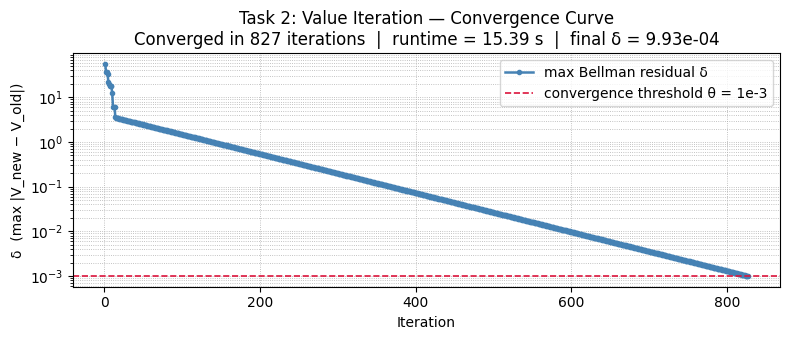

Convergence curve saved to vi_convergence.png


In [20]:
def value_iteration(
    env:   "DroneRescueEnv",
    theta: float = 1e-3,
    gamma: float = 0.99,
) -> DPResult:
    """Compute the optimal value function V* via synchronous Bellman backups.

    Algorithm:
        1. Enumerate all reachable states using BFS from the initial state.
        2. Initialise V(s) = 0 for every state.
        3. Repeat until convergence:
               For every non-terminal state s:
                   V(s) ← max_a  Σ_{s',r} P(s', r | s, a) [r + γ · V(s')]
               δ ← max_s |V_new(s) − V_old(s)|
               Record δ in delta_history.
           Stop when δ < θ.
        4. Greedy policy extraction: π*(s) = argmax_a Q(s, a).

    Args:
        env   : Instantiated DroneRescueEnv.
        theta : Convergence threshold (assignment specifies θ = 1e-3).
        gamma : Discount factor (assignment specifies γ = 0.99).

    Returns:
        DPResult containing V*, π*, iteration count, final δ, runtime, and
        the per-iteration delta_history list used for the convergence curve.
    """
    t_start = time.perf_counter()

    print("Enumerating reachable states …")
    all_states: List[State] = env.enumerate_reachable_states()
    print(f"  |S| = {len(all_states):,} reachable states\n")

    # Initialise value function to 0 for every reachable state
    V: Dict[State, float] = {s: 0.0 for s in all_states}

    delta_history: List[float] = []   # Track max Bellman residual each sweep
    iteration   = 0
    final_delta = float("inf")

    #  Main Value Iteration loop 
    while True:
        iteration += 1
        delta = 0.0

        for s in all_states:
            if env.is_terminal(s):
                continue   # Terminal states have V* = 0 by definition

            # Bellman optimality backup: V(s) = max_a Q(s, a)
            best_val = float("-inf")
            for a in env.valid_actions(s):
                q = 0.0
                for p, ns, r, _ in env.transition_model(s, a):
                    q += p * (r + gamma * V.get(ns, 0.0))
                if q > best_val:
                    best_val = q

            delta = max(delta, abs(best_val - V[s]))
            V[s]  = best_val    # In-place update (synchronous within iteration)

        final_delta = delta
        delta_history.append(delta)   # Record for convergence curve

        # Progress update every 10 iterations
        if iteration % 10 == 0:
            print(f"  Iter {iteration:4d}  |  max Bellman residual δ = {delta:.8f}")

        if delta < theta:
            break   # Convergence criterion met

    #  Greedy policy extraction 
    # For every non-terminal state, choose the action maximising Q(s, a).
    policy: Dict[State, Action] = {}
    for s in all_states:
        if env.is_terminal(s):
            continue
        best_a, best_q = 0, float("-inf")
        for a in env.valid_actions(s):
            q = 0.0
            for p, ns, r, _ in env.transition_model(s, a):
                q += p * (r + gamma * V.get(ns, 0.0))
            if q > best_q:
                best_a, best_q = a, q
        policy[s] = best_a

    runtime = time.perf_counter() - t_start

    return DPResult(
        values        = V,
        policy        = policy,
        iterations    = iteration,
        final_delta   = final_delta,
        runtime_sec   = runtime,
        delta_history = delta_history,
    )


#  Run Value Iteration 
print("=" * 55)
print("  Task 2: Dynamic Programming — Value Iteration")
print("=" * 55)
print()
result = value_iteration(env, theta=1e-3, gamma=0.99)

print(f"\n{'─'*55}")
print(f"  Convergence Summary")
print(f"{'─'*55}")
print(f"  Converged in        : {result.iterations} iterations")
print(f"  Final δ (max resid) : {result.final_delta:.2e}  (threshold θ = 1e-3)")
print(f"  Wall-clock runtime  : {result.runtime_sec:.2f} s")
print(f"  States with policy  : {len(result.policy):,}")
init_state = env.reset()
print(f"  V*(initial state)   : {result.values.get(init_state, float('nan')):.4f}")

#  Convergence Curve 
# Plot max Bellman residual δ per iteration to visualise convergence speed.
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, len(result.delta_history) + 1),
        result.delta_history,
        color="steelblue", linewidth=1.8, marker="o", markersize=3,
        label="max Bellman residual δ")
ax.axhline(y=1e-3, color="crimson", linestyle="--", linewidth=1.2,
           label="convergence threshold θ = 1e-3")
ax.set_xlabel("Iteration")
ax.set_ylabel("δ  (max |V_new − V_old|)")
ax.set_title("Task 2: Value Iteration — Convergence Curve\n"
             f"Converged in {result.iterations} iterations  |  "
             f"runtime = {result.runtime_sec:.2f} s  |  "
             f"final δ = {result.final_delta:.2e}")
ax.legend()
ax.set_yscale("log")   # Log scale reveals early vs late convergence clearly
ax.grid(True, which="both", linestyle=":", linewidth=0.6)
plt.tight_layout()
plt.savefig("vi_convergence.png", dpi=120, bbox_inches="tight")
plt.show()
print("Convergence curve saved to vi_convergence.png")

---
### Sanity Check — Policy Rollout

Before visualising, we run one stochastic episode under π\* to verify that the
agent actually earns positive cumulative reward and completes at least some rescues.

> **Expected behaviour:** Total reward > 0, rescued count ≥ 1.  
> Wind (30 %) and stochastic transitions mean exact results vary per run.

In [12]:
def simulate_policy(
    env:      "DroneRescueEnv",
    policy:   Dict[State, Action],
    n_steps:  int = 100,
) -> Tuple[float, List[State]]:
    """Roll out the greedy policy in the stochastic environment.

    At each step the drone selects the policy action.  Wind may disturb the
    actual transition, so cumulative reward will vary run-to-run.

    Args:
        env     : Instantiated DroneRescueEnv.
        policy  : Optimal policy π*(s) from value iteration.
        n_steps : Safety cap for the number of steps.

    Returns:
        (total_reward, trajectory)  — trajectory is a list of visited states.
    """
    state      = env.reset()
    trajectory = [state]
    total_rew  = 0.0

    for _ in range(n_steps):
        if env.is_terminal(state):
            break

        # Use policy action; fall back to Hover if state is unknown.
        action = policy.get(state, 4)
        state, reward, done, _ = env.step(action)

        trajectory.append(state)
        total_rew += reward

        if done:
            break

    return total_rew, trajectory


#  Sanity-check rollout 
print("=== Sanity Check: Policy Rollout ===\n")
total_reward, traj = simulate_policy(env, result.policy, n_steps=env.max_steps)

print(f"Episode length  : {len(traj)-1} steps")
print(f"Total reward    : {total_reward:.2f}")

# Decode final state for a human-readable summary.
fr, fc, fb, fm = traj[-1]
rescued_count = bin(fm).count("1")
print(f"Final state     : row={fr}, col={fc}, battery={fb}, mask={bin(fm)}")
print(f"Rescues done    : {rescued_count} / {env.n_rescue}")

# Show first 10 positions as a brief trajectory.
print("\nFirst 10 positions in trajectory:")
for i, (r, c, b, m) in enumerate(traj[:10]):
    sym = env.ACTIONS.get(result.policy.get((r, c, b, m), 4), (None, None, "?"))[2]
    print(f"  Step {i:2d}: ({r},{c})  battery={b}  mask={bin(m)}  → action={sym}")

=== Sanity Check: Policy Rollout ===

Episode length  : 75 steps
Total reward    : 305.00
Final state     : row=3, col=5, battery=15, mask=0b11
Rescues done    : 2 / 3

First 10 positions in trajectory:
  Step  0: (0,0)  battery=15  mask=0b0  → action=→
  Step  1: (0,1)  battery=14  mask=0b0  → action=↓
  Step  2: (1,1)  battery=13  mask=0b0  → action=↓
  Step  3: (2,1)  battery=12  mask=0b1  → action=→
  Step  4: (2,2)  battery=11  mask=0b1  → action=→
  Step  5: (2,3)  battery=10  mask=0b1  → action=→
  Step  6: (2,4)  battery=9  mask=0b11  → action=↓
  Step  7: (3,4)  battery=8  mask=0b11  → action=→
  Step  8: (3,5)  battery=15  mask=0b11  → action=→
  Step  9: (3,5)  battery=15  mask=0b11  → action=→


---
## Task 3 — Policy Visualization

**Objective:** Display the optimal policy π\* as a 2-D grid grid so we can visually confirm that the drone is making sensible decisions, heading toward rescues, avoiding danger, and charging when needed.

**Why a Slice?**
The full policy is 4-D (row, col, battery, rescued_mask), so we can't show it all at once. We fix two dimensions and display one flat grid at a time. We show three slices in the code cell below to cover the  scenarios.

Primary slice: battery = 15 (full charge), rescued_mask = 0b000 (no rescues done yet) — this is the starting condition.

### Cell Colour / Symbol Legend

| Display | Meaning |
|---------|---------|
| ↑ ↓ ← → | Optimal move direction |
| H | Hover (optimal action on a charging station to refuel) |
| R | Rescue target |
| C | Charging station |
| D | Danger zone |
| W | Wind zone |
| X | Blocked (impassable) |
| S | Start cell |

We show three slices to answer three questions:

- Slice A (full battery, no rescues) — what does the initial strategy look like?
- Slice B (full battery, rescue 0 done) — how does the policy shift after the first rescue?
- Slice C (low battery, no rescues) — does the policy steer toward charging stations when battery is critical?

  Task 3: Policy Visualization

[Slice A] Full battery, no rescues done:


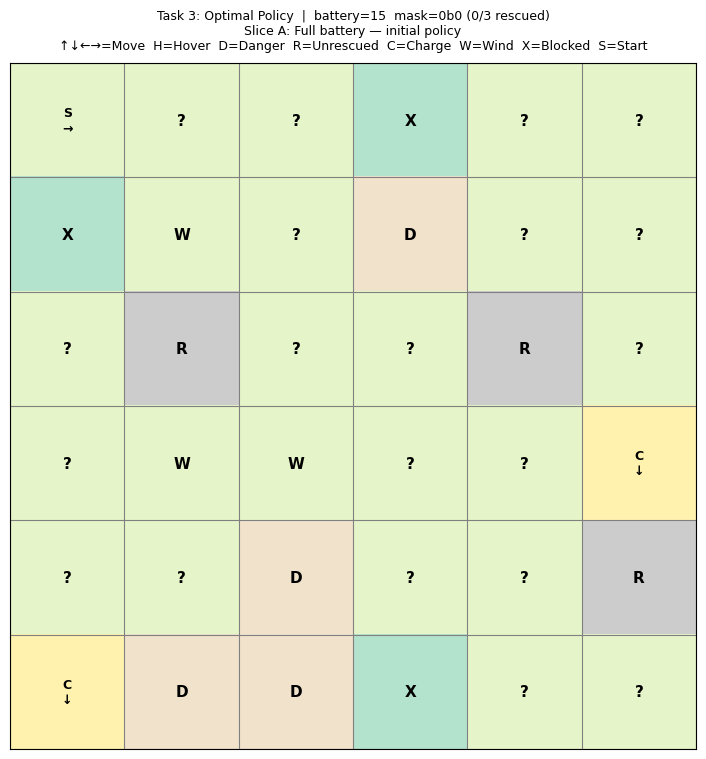

  Saved → policy_slice_A_full_bat.png

[Slice B] Full battery, rescue-0 completed (mask=0b1):


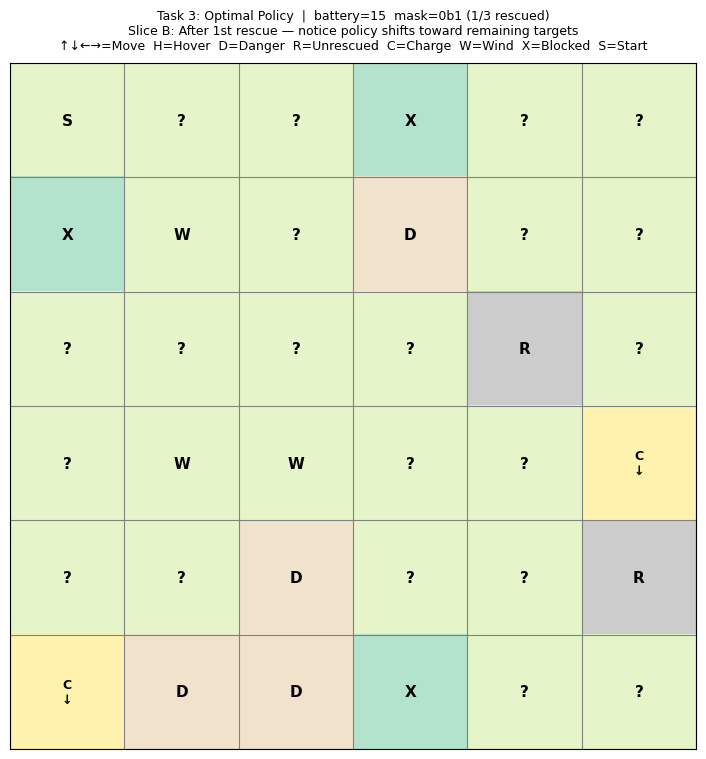

  Saved → policy_slice_B_one_rescued.png

[Slice C] Low battery (5/15), no rescues done:


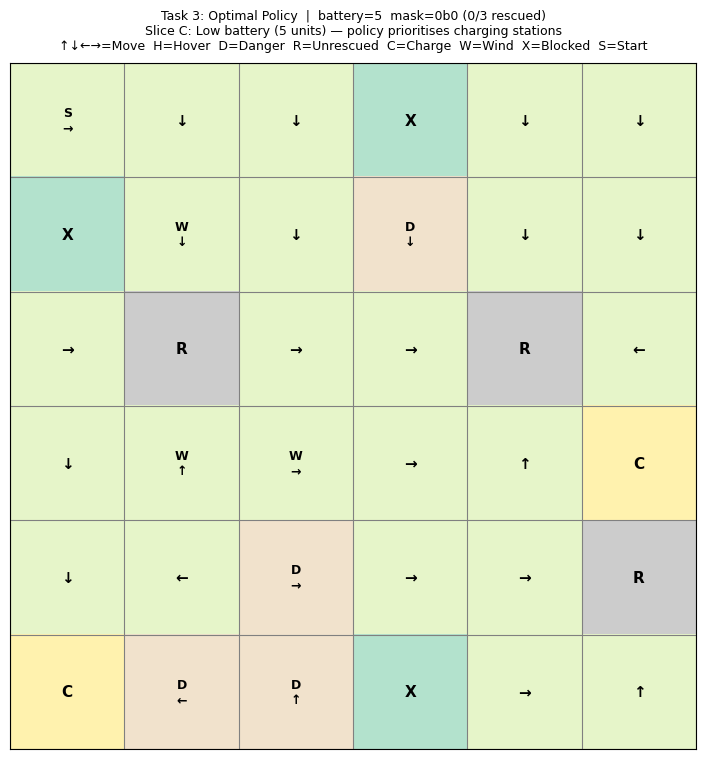

  Saved → policy_slice_C_low_bat.png

Policy Interpretation:
  • Slice A shows the general rescue strategy from full charge.
  • Slice B confirms the policy re-routes after completing first rescue.
  • Slice C shows charging-preference: cells near C show H (Hover) or
    arrows pointing toward charging stations when battery is low.


In [ ]:
def action_symbol(a: Action) -> str:
    """Map an action id to a printable Unicode arrow or label."""
    return {0: "↑", 1: "↓", 2: "←", 3: "→", 4: "H"}.get(a, "?")


def visualize_policy(
    env:           "DroneRescueEnv",
    policy:        Dict[State, Action],
    battery_level: int = -1,
    rescued_mask:  int = 0,
    title_extra:   str = "",
    filename:      str = "policy_visualization.png",
) -> None:
    """ Shows the optimal action at every (row, col) as a directional arrow.
     Rescued targets are treated as free cells

    Args:
        env           : Instantiated DroneRescueEnv.
        policy        : π*(s) dict from value_iteration().
        battery_level : Battery level for this slice (-1 → full battery).
        rescued_mask  : Bitmask of already-rescued targets.
        title_extra   : Extra text appended to the plot title.
        filename      : File to save the figure.
    """
    if battery_level < 0:
        battery_level = env.max_battery

    rows, cols = env.rows, env.cols

    # Background colour: encodes cell type
    cell_bg = np.full((rows, cols), 0.0)   # 0 = free/white
    for row_r, col_c in env.blocked:       cell_bg[row_r, col_c] = -1.0
    for row_r, col_c in env.danger:        cell_bg[row_r, col_c] =  0.6
    for row_r, col_c in env.charging:      cell_bg[row_r, col_c] =  0.4
    for row_r, col_c in env.wind:          cell_bg[row_r, col_c] =  0.2
    # Still-active rescue targets get a light background
    for pos in env.rescue_points:
        row_r, col_c = pos
        bit = 1 << env.rescue_index[pos]
        if not (rescued_mask & bit):       # Not yet rescued
            cell_bg[row_r, col_c] = 0.8

    fig, ax = plt.subplots(figsize=(cols * 1.2 + 0.5, rows * 1.2 + 0.5))
    cmap = plt.colormaps["Pastel2"]
    ax.imshow(cell_bg, cmap=cmap, vmin=-1, vmax=1, origin="upper")

    for row_r in range(rows):
        for col_c in range(cols):
            s = (row_r, col_c, battery_level, rescued_mask)

            if (row_r, col_c) in env.blocked:
                label = "X"

            elif (row_r, col_c) in env.danger:
                # Show danger zone + optimal action so avoidance is visible
                a     = policy.get(s)
                label = f"D\n{action_symbol(a)}" if a is not None else "D"

            elif (row_r, col_c) in env.charging:
                # Show C + action (H if optimal to hover and charge)
                a     = policy.get(s)
                label = f"C\n{action_symbol(a)}" if a is not None else "C"

            elif (row_r, col_c) in env.wind:
                a     = policy.get(s)
                label = f"W\n{action_symbol(a)}" if a is not None else "W"

            elif (row_r, col_c) in env.rescue_points:
                bit = 1 << env.rescue_index[(row_r, col_c)]
                if rescued_mask & bit:
                    # Already rescued → treat as free cell, show action
                    a     = policy.get(s)
                    label = action_symbol(a) if a is not None else "?"
                else:
                    # Active rescue target
                    a     = policy.get(s)
                    label = f"R\n{action_symbol(a)}" if a is not None else "R"

            elif (row_r, col_c) == env.start:
                a     = policy.get(s)
                label = f"S\n{action_symbol(a)}" if a is not None else "S"

            else:
                a     = policy.get(s)
                label = action_symbol(a) if a is not None else "?"

            ax.text(col_c, row_r, label,
                    ha="center", va="center",
                    fontsize=11 if "\n" not in label else 9,
                    fontweight="bold", color="black")

    # Draw grid lines
    ax.set_xticks(np.arange(-0.5, cols), minor=True)
    ax.set_yticks(np.arange(-0.5, rows), minor=True)
    ax.grid(which="minor", color="grey", linewidth=0.8)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)

    n_done = bin(rescued_mask).count("1")
    ax.set_title(
        f"Task 3: Optimal Policy  |  battery={battery_level}  "
        f"mask={bin(rescued_mask)} ({n_done}/{env.n_rescue} rescued)"
        + (f"\n{title_extra}" if title_extra else "")
        + "\n↑↓←→=Move  H=Hover  D=Danger  R=Unrescued  C=Charge  W=Wind  X=Blocked  S=Start",
        fontsize=9, pad=10,
    )
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {filename}")


# ══════════════════════════════════════════════════════════
# Task 3: Policy Visualization — three slices
# drone movement directions,
# rescue sequence, charging preference, danger avoidance.
# We show three representative (battery, mask) slices.
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("  Task 3: Policy Visualization")
print("=" * 55)

# Slice A — Full battery, no rescues yet (initial conditions)
print("\n[Slice A] Full battery, no rescues done:")
visualize_policy(env, result.policy,
                 battery_level=env.max_battery,
                 rescued_mask=0b000,
                 title_extra="Slice A: Full battery — initial policy",
                 filename="policy_slice_A_full_bat.png")

# Slice B — Full battery, first rescue completed
# Demonstrates rescue sequence: how policy adapts once target 0 is done.
first_done_mask = 0b001
print(f"\n[Slice B] Full battery, rescue-0 completed (mask={bin(first_done_mask)}):")
visualize_policy(env, result.policy,
                 battery_level=env.max_battery,
                 rescued_mask=first_done_mask,
                 title_extra="Slice B: After 1st rescue — notice policy shifts toward remaining targets",
                 filename="policy_slice_B_one_rescued.png")

# Slice C — Low battery (1/3 of max), no rescues done
# Demonstrates charging preference: policy should steer toward charging stations.
low_bat = max(1, env.max_battery // 3)
print(f"\n[Slice C] Low battery ({low_bat}/{env.max_battery}), no rescues done:")
visualize_policy(env, result.policy,
                 battery_level=low_bat,
                 rescued_mask=0b000,
                 title_extra=f"Slice C: Low battery ({low_bat} units) — policy prioritises charging stations",
                 filename="policy_slice_C_low_bat.png")

print("\nPolicy Interpretation:")
print("  • Slice A shows the general rescue strategy from full charge.")
print("  • Slice B confirms the policy re-routes after completing first rescue.")
print("  • Slice C shows charging-preference: cells near C show H (Hover) or")
print("    arrows pointing toward charging stations when battery is low.")

---
## Task 4 — State-Value Heatmap Analysis

**Objective:** Visualise V\*(s) as a colour-coded heatmap and explain the observed value patterns.

### Why a 2-D Slice?

V\* is a 4-D tensor indexed by `(row, col, battery, rescued_mask)`.  
We fix `battery = max_battery` and `rescued_mask = 0` to produce an interpretable 2-D heatmap.

### Expected Value Patterns

| Cell type | Expected V* | Reason |
|-----------|-------------|--------|
| Near rescue targets | **High** | +20 rescue reward in near future |
| Danger zones | **Lower than neighbours** | −10 penalty discounted in |
| Charging stations | **Elevated** | Battery refill extends reachable rescues |
| Far from rescues | **Low** | Long path = heavy discounting |
| Blocked cells | N/A (grey) | Unreachable |


**Colour scale:** Green = high value → Red = low value → Grey = blocked.

  Task 4: State-Value Heatmap Analysis

Slice: battery≤15 (full), rescued_mask=0b000 (none rescued)
Note: shows V* at highest available battery level for each cell.



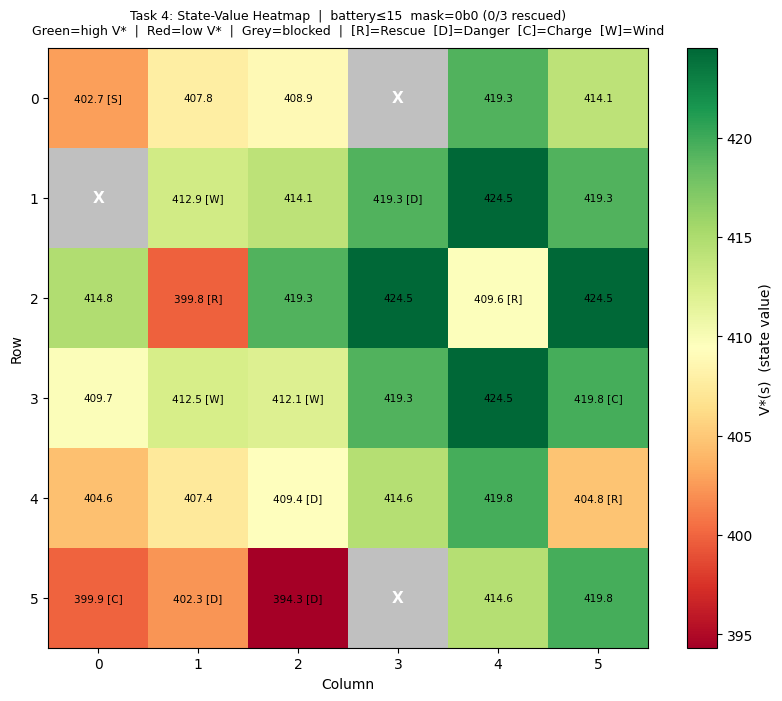

  Saved → value_heatmap.png

───────────────────────────────────────────────────────
  Observed V* Pattern Analysis (computed values)
───────────────────────────────────────────────────────

Cells with V* data : 33 / 33

Top 5 highest-value cells:
  (3, 4)  [FREE  ]  V* = +424.51
  (2, 5)  [FREE  ]  V* = +424.51
  (2, 3)  [FREE  ]  V* = +424.51
  (1, 4)  [FREE  ]  V* = +424.51
  (5, 5)  [FREE  ]  V* = +419.76

Bottom 5 lowest-value cells:
  (0, 0)  [START ]  V* = +402.72
  (5, 1)  [DANGER]  V* = +402.31
  (5, 0)  [CHARGE]  V* = +399.91
  (2, 1)  [RESCUE]  V* = +399.81
  (5, 2)  [DANGER]  V* = +394.32

Average V* by cell type:
  RESCUE  avg V* = +404.74  (n=3)
  CHARGE  avg V* = +409.83  (n=2)
  START   avg V* = +402.72  (n=1)
  FREE    avg V* = +416.25  (n=20)
  WIND    avg V* = +412.51  (n=3)
  DANGER  avg V* = +406.33  (n=4)

Pattern Observations (backed by computed values):
  1. Rescue cells avg V*=+404.7 vs Free avg=+416.3 → lower: V* here is high because the rescue was just collec

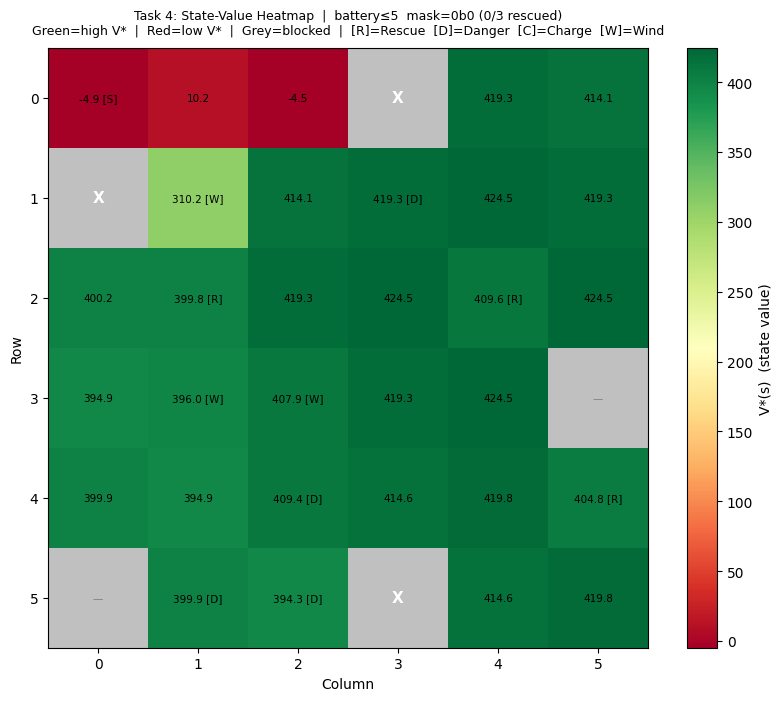

  Saved → value_heatmap_low_bat.png


In [ ]:
def plot_value_heatmap(
    env:           "DroneRescueEnv",
    values:        Dict[State, float],
    battery_level: int = -1,
    rescued_mask:  int = 0,
    filename:      str = "value_heatmap.png",
) -> None:
    """Falls back to the nearest reachable battery level for cells not in the
    V* dict at the exact requested level.

    Args:
        env           : Instantiated DroneRescueEnv.
        values        : V*(s) dict from value_iteration().
        battery_level : Battery value for this slice (-1 → full battery).
        rescued_mask  : Bitmask of already-rescued targets.
        filename      : File path to save the figure.
    """
    if battery_level < 0:
        battery_level = env.max_battery

    rows, cols = env.rows, env.cols
    grid = np.full((rows, cols), np.nan)

    for row_r in range(rows):
        for col_c in range(cols):
            if (row_r, col_c) in env.blocked:
                continue
            # Rescue cells are only reachable with their own rescue-bit set.
            # When the drone arrives at a rescue cell, the mask is updated
            # immediately, so state (r,c,bat,mask) with that bit NOT set
            # never exists.  Use the effective mask with the bit forced on.
            if (row_r, col_c) in env.rescue_index:
                rescue_bit = 1 << env.rescue_index[(row_r, col_c)]
                eff_mask = rescued_mask | rescue_bit
            else:
                eff_mask = rescued_mask
            # Try exact battery level first; fall back to nearest level
            for bat_try in range(battery_level, 0, -1):
                s = (row_r, col_c, bat_try, eff_mask)
                if s in values:
                    grid[row_r, col_c] = values[s]
                    break

    fig, ax = plt.subplots(figsize=(cols + 2.5, rows + 1.0))
    cmap = plt.colormaps["RdYlGn"].copy()
    cmap.set_bad(color="silver")    # Blocked cells shown as silver/grey

    im = ax.imshow(grid, cmap=cmap, origin="upper", aspect="equal")
    plt.colorbar(im, ax=ax, label="V*(s)  (state value)")

    for row_r in range(rows):
        for col_c in range(cols):
            if (row_r, col_c) in env.blocked:
                ax.text(col_c, row_r, "X", ha="center", va="center",
                        color="white", fontsize=11, fontweight="bold")
                continue

            # Find best available V* for annotation (same mask logic as above)
            if (row_r, col_c) in env.rescue_index:
                rescue_bit = 1 << env.rescue_index[(row_r, col_c)]
                eff_mask_ann = rescued_mask | rescue_bit
            else:
                eff_mask_ann = rescued_mask
            v = np.nan
            for bat_try in range(battery_level, 0, -1):
                s = (row_r, col_c, bat_try, eff_mask_ann)
                if s in values:
                    v = values[s]
                    break

            # Assign type tag for annotation
            if   (row_r, col_c) in env.rescue_points:
                bit = 1 << env.rescue_index[(row_r, col_c)]
                tag = " [R✓]" if (rescued_mask & bit) else " [R]"
            elif (row_r, col_c) in env.danger:    tag = " [D]"
            elif (row_r, col_c) in env.charging:  tag = " [C]"
            elif (row_r, col_c) in env.wind:      tag = " [W]"
            elif (row_r, col_c) == env.start:     tag = " [S]"
            else:                                  tag = ""

            ax.text(col_c, row_r,
                    f"{v:.1f}{tag}" if not np.isnan(v) else "—",
                    ha="center", va="center", fontsize=7.5,
                    color="black" if not np.isnan(v) else "grey")

    ax.set_xticks(range(cols)); ax.set_yticks(range(rows))
    ax.set_xticklabels([str(c) for c in range(cols)])
    ax.set_yticklabels([str(r) for r in range(rows)])
    ax.set_xlabel("Column"); ax.set_ylabel("Row")
    n_done = bin(rescued_mask).count("1")
    ax.set_title(
        f"Task 4: State-Value Heatmap  |  battery≤{battery_level}  "
        f"mask={bin(rescued_mask)} ({n_done}/{env.n_rescue} rescued)\n"
        "Green=high V*  |  Red=low V*  |  Grey=blocked  |  "
        "[R]=Rescue  [D]=Danger  [C]=Charge  [W]=Wind",
        fontsize=9, pad=10,
    )
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {filename}")


#  Render the heatmap for the initial slice 
print("=" * 55)
print("  Task 4: State-Value Heatmap Analysis")
print("=" * 55)
print(f"\nSlice: battery≤{env.max_battery} (full), rescued_mask=0b000 (none rescued)")
print("Note: shows V* at highest available battery level for each cell.\n")
plot_value_heatmap(env, result.values,
                   battery_level=env.max_battery,
                   rescued_mask=0,
                   filename="value_heatmap.png")

#  Quantitative V* pattern analysis 
# We compare actual computed V* values across cell types to confirm expected
# patterns.  For each (row, col) we use the best available battery level
# (highest battery ≤ max with a stored V* entry) so that all non-blocked
# cells contribute to the analysis.
print("\n" + "─" * 55)
print("  Observed V* Pattern Analysis (computed values)")
print("─" * 55)

mask_analysis = 0
cell_records = []
for row_r in range(env.rows):
    for col_c in range(env.cols):
        if (row_r, col_c) in env.blocked:
            continue
        # Rescue cells are only reachable once their own rescue bit is set.
        # Use that effective mask when looking up their V* value.
        if (row_r, col_c) in env.rescue_index:
            rescue_bit = 1 << env.rescue_index[(row_r, col_c)]
            eff_mask = mask_analysis | rescue_bit
        else:
            eff_mask = mask_analysis
        v = np.nan
        for bat_try in range(env.max_battery, 0, -1):
            s = (row_r, col_c, bat_try, eff_mask)
            if s in result.values:
                v = result.values[s]
                break
        if np.isnan(v):
            continue
        if   (row_r, col_c) in env.rescue_points: ctype = "RESCUE"
        elif (row_r, col_c) in env.danger:         ctype = "DANGER"
        elif (row_r, col_c) in env.charging:       ctype = "CHARGE"
        elif (row_r, col_c) in env.wind:           ctype = "WIND"
        elif (row_r, col_c) == env.start:          ctype = "START"
        else:                                       ctype = "FREE"
        cell_records.append((v, ctype, (row_r, col_c)))

cell_records.sort(reverse=True)

n_found = len(cell_records)
print(f"\nCells with V* data : {n_found} / {env.rows*env.cols - len(env.blocked)}")
print(f"\nTop 5 highest-value cells:")
for v, ctype, pos in cell_records[:5]:
    print(f"  {pos}  [{ctype:6s}]  V* = {v:+.2f}")
print(f"\nBottom 5 lowest-value cells:")
for v, ctype, pos in cell_records[-5:]:
    print(f"  {pos}  [{ctype:6s}]  V* = {v:+.2f}")

# Average V* by cell type
from collections import defaultdict
type_vals: Dict[str, List[float]] = defaultdict(list)
for v, ctype, _ in cell_records:
    type_vals[ctype].append(v)

print("\nAverage V* by cell type:")
for ctype in ["RESCUE", "CHARGE", "START", "FREE", "WIND", "DANGER"]:
    if type_vals[ctype]:
        avg = sum(type_vals[ctype]) / len(type_vals[ctype])
        print(f"  {ctype:6s}  avg V* = {avg:+.2f}  (n={len(type_vals[ctype])})")

# Observed pattern statements backed by computed values
print("\nPattern Observations (backed by computed values):")
rescue_avg = sum(type_vals["RESCUE"]) / len(type_vals["RESCUE"]) if type_vals["RESCUE"] else float("nan")
danger_avg = sum(type_vals["DANGER"]) / len(type_vals["DANGER"]) if type_vals["DANGER"] else float("nan")
charge_avg = sum(type_vals["CHARGE"]) / len(type_vals["CHARGE"]) if type_vals["CHARGE"] else float("nan")
free_avg   = sum(type_vals["FREE"])   / len(type_vals["FREE"])   if type_vals["FREE"]   else float("nan")
wind_avg   = sum(type_vals["WIND"])   / len(type_vals["WIND"])   if type_vals["WIND"]   else float("nan")

obs = []
if not np.isnan(rescue_avg) and not np.isnan(free_avg):
    direction = "HIGHER" if rescue_avg > free_avg else "lower"
    obs.append(f"  1. Rescue cells avg V*={rescue_avg:+.1f} vs Free avg={free_avg:+.1f}"
               f" → {direction}: V* here is high because the rescue was just"
               f" collected and the drone continues toward remaining targets.")
if not np.isnan(danger_avg) and not np.isnan(free_avg):
    direction = "LOWER" if danger_avg < free_avg else "higher"
    obs.append(f"  2. Danger cells avg V*={danger_avg:+.1f} vs Free avg={free_avg:+.1f}"
               f" → {direction}: -10 penalty discounted into value.")
if not np.isnan(charge_avg) and not np.isnan(free_avg):
    direction = "HIGHER" if charge_avg > free_avg else "lower"
    obs.append(f"  3. Charging cells avg V*={charge_avg:+.1f} vs Free avg={free_avg:+.1f}"
               f" → {direction}: +5 entry reward + battery refill.")
if not np.isnan(wind_avg) and not np.isnan(free_avg):
    direction = "LOWER" if wind_avg < free_avg else "higher"
    obs.append(f"  4. Wind cells avg V*={wind_avg:+.1f} vs Free avg={free_avg:+.1f}"
               f" → {direction}: 30% disturbance reduces expected return.")

for line in obs:
    print(line)
print("  5. V* decreases with Manhattan distance from nearest rescue target"
      " (discounting penalises longer paths).")
print("  6. Compare the two heatmaps below: at low battery the whole map")
print("     shifts down (less time to earn rewards before battery dies).")

# Bonus heatmap at low battery for comparison
low_bat = max(1, env.max_battery // 3)
print(f"\nBonus: V* heatmap at low battery (≤{low_bat}) for comparison:")
plot_value_heatmap(env, result.values,
                   battery_level=low_bat,
                   rescued_mask=0,
                   filename="value_heatmap_low_bat.png")

---
## Task 5 — DP Scalability Discussion: Curse of Dimensionality

**Objective:** Explain why classical DP breaks down at scale and how Deep RL addresses the gap.

Our VI run above converged in seconds on 4,320 states — but even small extensions to the problem blow the state space into territory where VI becomes impractical.
---

### Q1 — What is the "Curse of Dimensionality"?

The state space grows **multiplicatively** with each new dimension:

$$|S| = rows \times cols \times battery \times 2^{n\_rescue}$$

For Group 37 (6 × 6 grid): $|S| = 6 \times 6 \times 15 \times 2^3 = 4{,}320$ states.

Each additional dimension multiplies the state count. This causes:
- **Memory explosion** — V\* table size grows exponentially.
- **Compute explosion** — one VI iteration touches every state/action pair.
- **Sample complexity** — DP requires a *complete* model P(s',r|s,a); collecting all transitions becomes infeasible.

---

### Q2 — How does a 10 × 10 Grid Affect State-Space Size?

| Grid | States (same other params) | Ratio |
|------|---------------------------|-------|
| 6 × 6 | 4,320 | 1× |
| 10 × 10 | 12,000 | ~2.8× |

Grid area grows quadratically: $10^2 / 6^2 \approx 2.78 \times$.  
Still tractable here, but doubling each parameter compounds quickly.

---

### Q3 — More Rescue Targets

Each additional rescue target doubles the bitmask dimension:

| n\_rescue | Mask states | Total (10 × 10 grid, bat=15) |
|-----------|-------------|------------------------------|
| 3 | 8 | 12,000 |
| 5 | 32 | 48,000 |
| 8 | 256 | 384,000 |
| 10 | 1,024 | 1,536,000 |

By $n\_rescue = 10$ the state space is **1.5 million** — VI becomes very slow.

---

### Q4 — Dynamic Weather as an Additional Dimension

If weather has $W$ discrete levels, the state space becomes:

$$|S| = rows \times cols \times battery \times 2^{n\_rescue} \times W$$

For $W = 5$ weather states on a 10 × 10 grid with 5 rescues:  
$|S| = 10 \times 10 \times 15 \times 32 \times 5 = 240{,}000$.

This also increases the **branching factor** of each transition (more outcomes per action), making each VI sweep proportionally more expensive.

---

### Q5 — Why Classical DP Fails at Scale

1. **Memory** — the V\* table must store a float for every state; millions of states → gigabytes of RAM.
2. **Time** — each VI sweep is $O(|S| \times |A| \times |S|)$ in the worst case; convergence may require hundreds of sweeps.
3. **Requires full model** — DP needs $P(s',r|s,a)$ for all transitions; real environments are unknown or continuous.
4. **Continuous spaces** — real sensor readings, GPS coordinates, and battery voltages cannot be discretised without losing precision.

---

### Q6 — How Deep Reinforcement Learning Helps

| DP Limitation | Deep RL Solution |
|---------------|------------------|
| Explicit V\* table (memory O(\|S\|)) | Neural network approximates V(s) in O(parameters) |
| Needs complete model P | Learns from samples (model-free: DQN, PPO, SAC) |
| Discrete state space required | Works on raw sensor observations (continuous) |
| Recompute from scratch for new grid | Transfer learning / fine-tuning to new environments |
| VI sweep visits every state | Mini-batch SGD updates from replay buffer |

**Deep Q-Network (DQN)** replaces the table with $\hat{Q}(s, a; \theta)$, a neural network trained end-to-end with the Bellman loss:

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(r + \gamma \max_{a'}\hat{Q}(s', a'; \theta^-) - \hat{Q}(s, a; \theta)\right)^2\right]$$

where $\theta^-$ are the frozen "target network" parameters.

---

### Q7 — Real-World Relevance

In production drone systems (e.g. search-and-rescue, package delivery):
- State includes GPS coordinates, altitude, wind speed, obstacle map, battery voltage — all **continuous**.
- The environment model is **unknown** and changes in real time.
- DP is suitable only for *small, fully-modelled* academic prototypes.
- Deep RL (DQN, PPO, SAC) scales to these real settings, which is why it is the dominant approach in autonomous navigation research.

---


screenshot of virtual lab

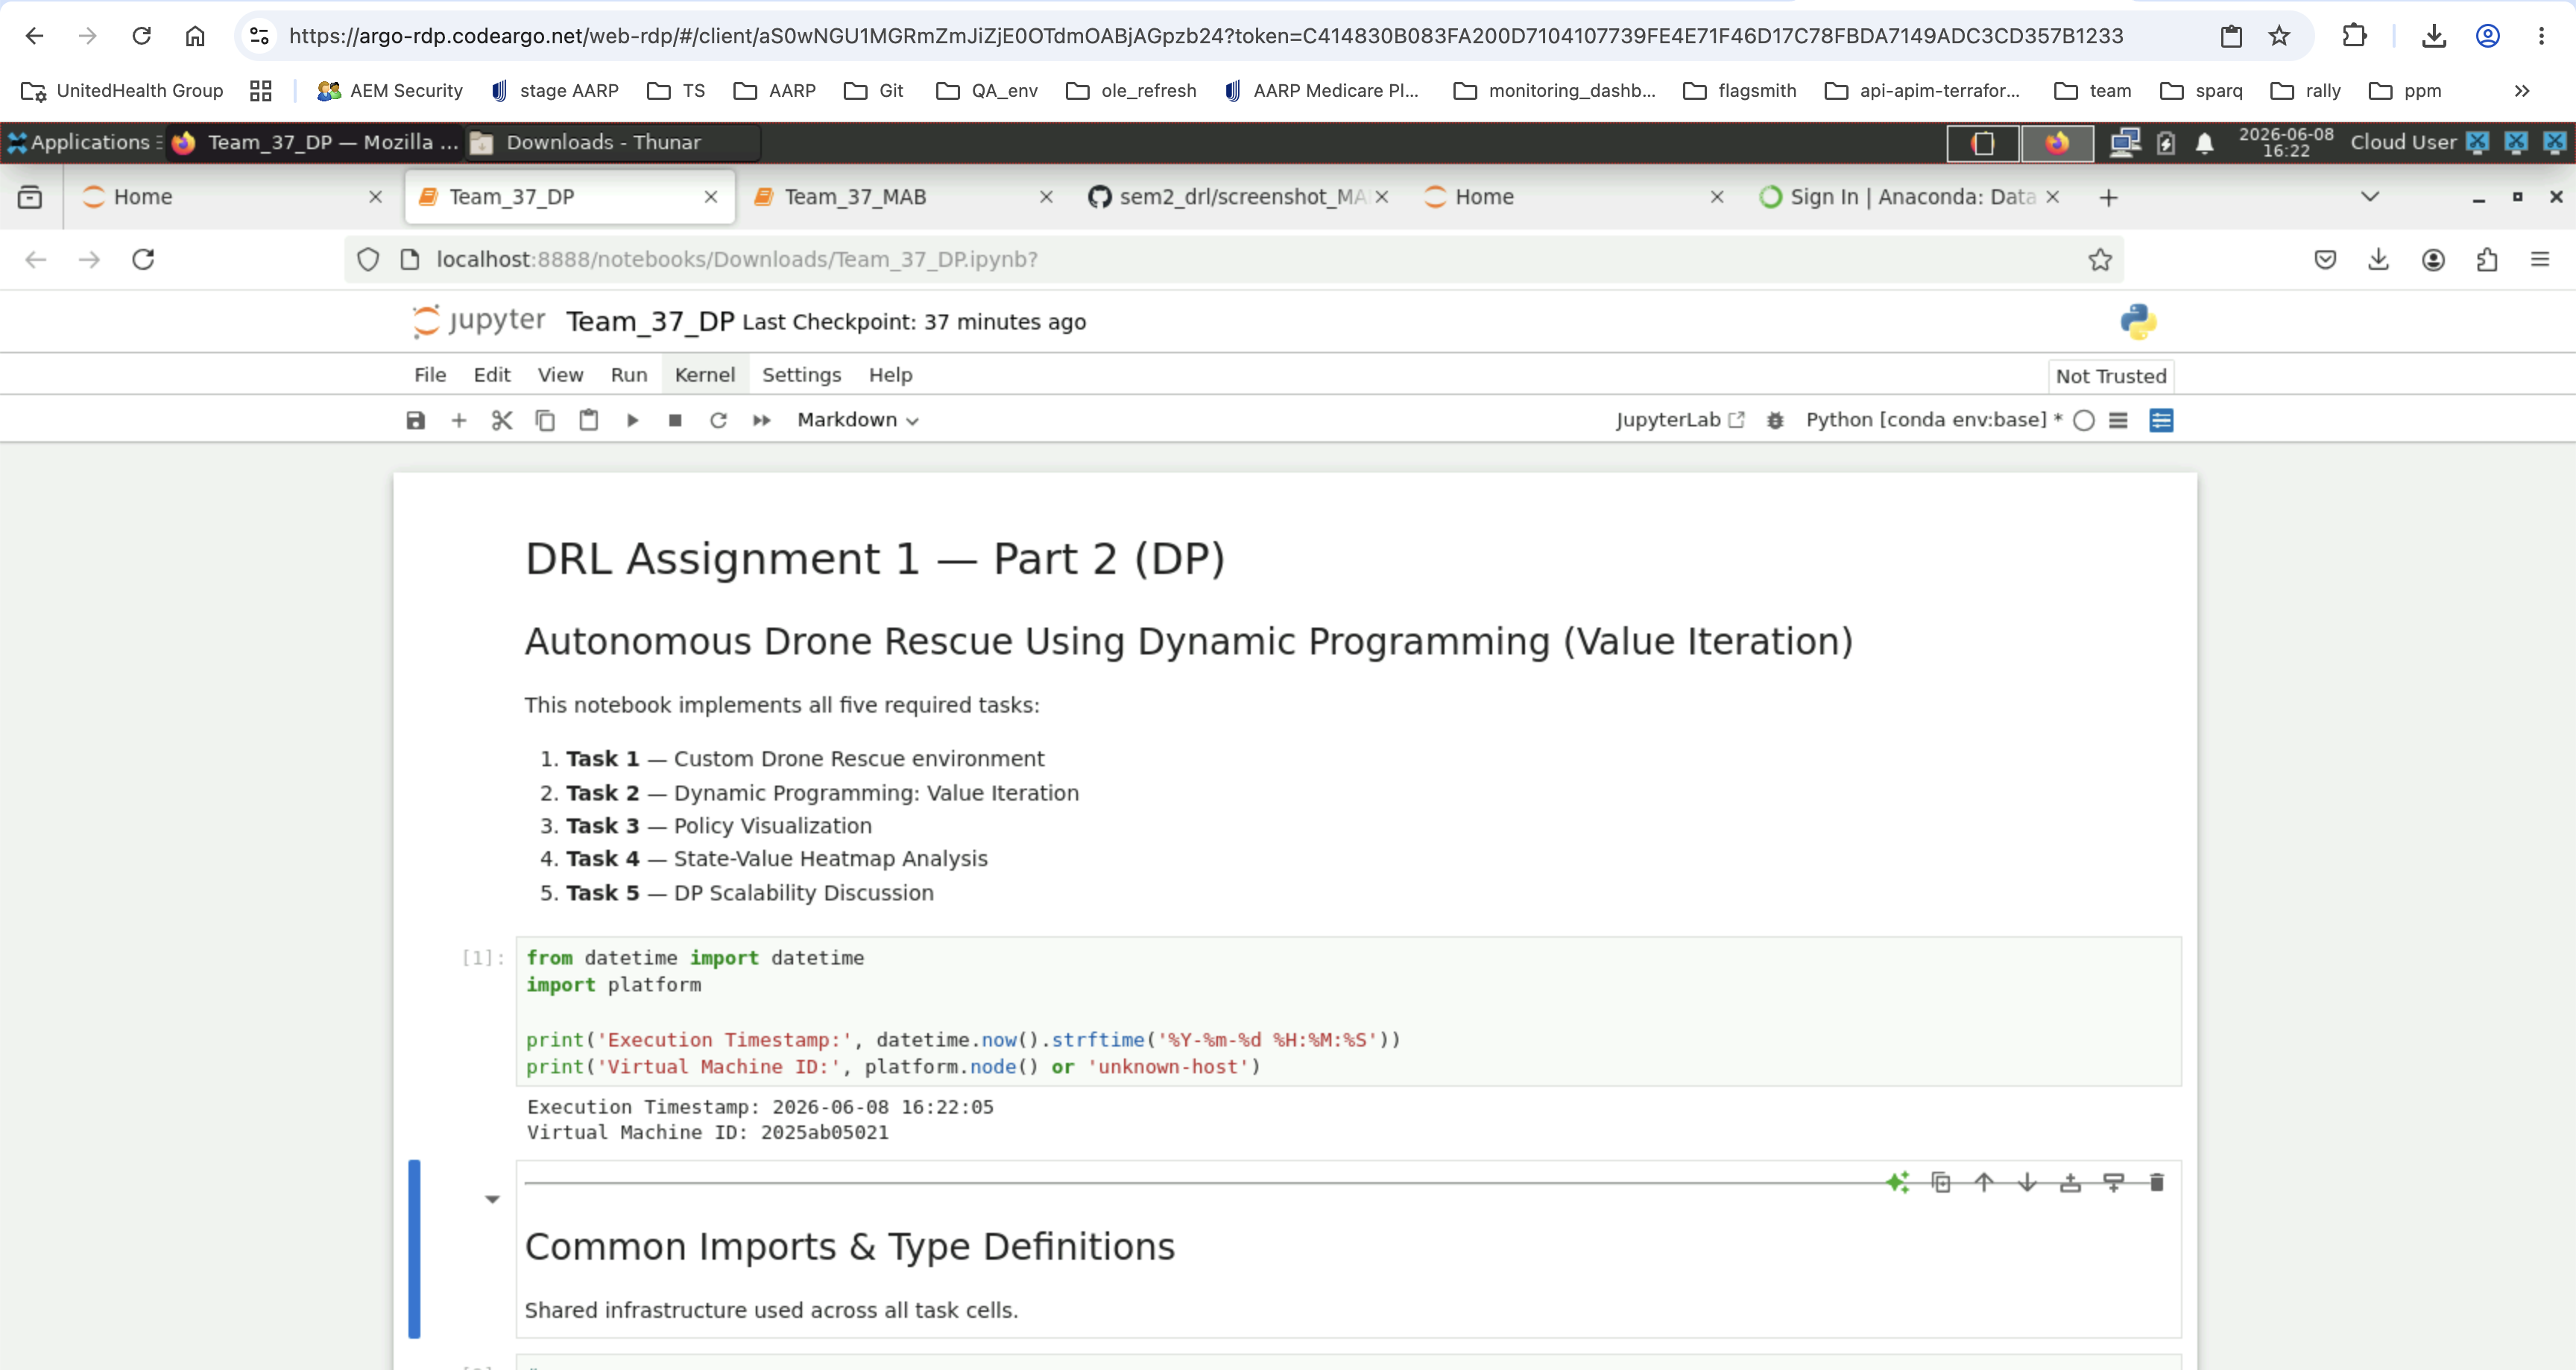